### **Clustering data (text + sequences) with uniref id**

**Load and Align the Data**

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
import scipy.sparse
import hdbscan
import umap
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Load original text dataset to get the EXACT order of 1037 proteins
text_df = pd.read_csv('../data/processed/uniprot_all_fields_cache.csv')
text_df = text_df.rename(columns={'Entry': 'ID'})
master_ids = text_df['ID'].tolist()

# Load saved Text Embeddings
sbert_embeddings = np.load('../data/processed/embeddings_sbert.npy')
tfidf_embeddings = scipy.sparse.load_npz('../data/processed/embeddings_tfidf.npz')

**Run this cell or next cell for having different sequence embeddings based on different normalizers**


In [36]:

# Load the NEW sequence embeddings based on another normalizer
new_seq_path = '../data/processed/embedding_sequences_mean_pooling.csv'
seq_df = pd.read_csv(new_seq_path)

# Handle the ID column name (just in case they named it 'Unnamed: 0' or 'uniref_id')
if 'Unnamed: 0' in seq_df.columns:
    seq_df = seq_df.rename(columns={'Unnamed: 0': 'ID'})
elif 'uniref_id' in seq_df.columns:
    seq_df = seq_df.rename(columns={'uniref_id': 'ID'})

# Filter sequence data to ONLY keep IDs that exist in text data
aligned_seq_df = seq_df[seq_df['ID'].isin(master_ids)]

# Force the rows into the exact same order as master_ids
aligned_seq_df = aligned_seq_df.set_index('ID').reindex(master_ids).reset_index()

# Extract the 1280 columns of the new ESM-2 embeddings
sequence_embeddings = aligned_seq_df.iloc[:, 1:1281].values 

print("Inner Join and Alignment Successful!")
print(f"  • Master Text Proteins: {len(master_ids)}")
print(f"  • New Seq Embeddings Shape: {sequence_embeddings.shape}")


Inner Join and Alignment Successful!
  • Master Text Proteins: 1037
  • New Seq Embeddings Shape: (1037, 1280)


In [ ]:
# # Load sequence data
# seq_df = pd.read_csv('../data/processed/data_with_embeddings.csv')
# seq_df = seq_df.rename(columns={'Unnamed: 0': 'ID'})

# # ALIGNMENT: Sort the sequence dataframe so it perfectly matches the text rows
# seq_df = seq_df.set_index('ID').reindex(master_ids).reset_index()

# # Extract just the 1280 columns of ESM-2 embeddings
# sequence_embeddings = seq_df.iloc[:, 1:1281].values 

In [37]:
print("All embeddings loaded and aligned!")
print(f"  • TF-IDF Shape: {tfidf_embeddings.shape}")
print(f"  • SBERT Shape:  {sbert_embeddings.shape}")
print(f"  • ESM-2 Shape:  {sequence_embeddings.shape}")

All embeddings loaded and aligned!
  • TF-IDF Shape: (1037, 514)
  • SBERT Shape:  (1037, 384)
  • ESM-2 Shape:  (1037, 1280)


**Calculate All 3 Distance Matrices**

In [38]:
print("Calculating Cosine Distance Matrices...")

# TF-IDF Distance
tfidf_sim = cosine_similarity(tfidf_embeddings)
tfidf_dist = np.clip(1 - tfidf_sim, 0, None)
np.fill_diagonal(tfidf_dist, 0)

# SBERT Distance
sbert_sim = cosine_similarity(sbert_embeddings)
sbert_dist = np.clip(1 - sbert_sim, 0, None)
np.fill_diagonal(sbert_dist, 0)

# ESM-2 Sequence Distance
esm2_sim = cosine_similarity(sequence_embeddings)
esm2_dist = np.clip(1 - esm2_sim, 0, None)
np.fill_diagonal(esm2_dist, 0)

print("All Distance Matrices created (Size: 1037 x 1037)!")

Calculating Cosine Distance Matrices...
All Distance Matrices created (Size: 1037 x 1037)!


**The Multi-Modal Fusion**

In [39]:
# Build the Text Hybrid (70% Keywords / 30% Sentences)
text_hybrid_dist = (0.7 * tfidf_dist) + (0.3 * sbert_dist)

# Build the Final Super-Matrix (50% Text / 50% Sequence)
super_matrix_dist = (0.5 * text_hybrid_dist) + (0.5 * esm2_dist)

super_matrix_dist = np.clip(super_matrix_dist, 0, None)
np.fill_diagonal(super_matrix_dist, 0)

**Run HDBSCAN for Clustering**

In [40]:
print("Running HDBSCAN Clustering...")

# min_cluster_size=5 means
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5, 
    min_samples=5,      
    metric='precomputed'
)

# Fit the model and attach labels to our dataframe
text_df['super_cluster'] = clusterer.fit_predict(super_matrix_dist)
labels = text_df['super_cluster'].values

# Calculate cluster statistics
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("\n HDBSCAN Results:")
print(f"  • Total Sub-families Found: {n_clusters}")
print(f"  • Proteins classified as 'Noise' (-1): {n_noise} out of {len(text_df)}")

# Silhouette Score (Excluding the noise points)
mask = labels != -1 
if mask.sum() > 0:
    sil = silhouette_score(super_matrix_dist[mask][:, mask], labels[mask], metric='precomputed')
    print(f"  • Silhouette Score (Cleaned Data): {sil:.4f}")
else:
    print("  • Not enough clustered points to calculate Silhouette Score.")
print("-" * 80)

# Pick 3 random valid clusters to inspect
valid_clusters = [c for c in set(labels) if c != -1 and list(labels).count(c) >= 5]

if valid_clusters:
    sample_clusters = np.random.choice(valid_clusters, min(3, len(valid_clusters)), replace=False)
    for cluster_id in sample_clusters:
        cluster_data = text_df[text_df['super_cluster'] == cluster_id]
        print(f"\nSample Cluster  {cluster_id} (Size: {len(cluster_data)})")
        for idx, row in cluster_data.head(4).iterrows():
            protein_name = str(row.get('Protein names', 'Unknown Protein'))
            print(f"  🔹 {protein_name[:150]}...")
        print("-" * 80)

Running HDBSCAN Clustering...

 HDBSCAN Results:
  • Total Sub-families Found: 58
  • Proteins classified as 'Noise' (-1): 272 out of 1037
  • Silhouette Score (Cleaned Data): 0.7329
--------------------------------------------------------------------------------

Sample Cluster  6 (Size: 8)
  🔹 Beta-2 adrenergic receptor (Beta-2 adrenoceptor) (Beta-2 adrenoreceptor)...
  🔹 Beta-2 adrenergic receptor (Beta-2 adrenoceptor) (Beta-2 adrenoreceptor)...
  🔹 Beta-2 adrenergic receptor (Beta-2 adrenoceptor) (Beta-2 adrenoreceptor)...
  🔹 Beta-2 adrenergic receptor (Beta-2 adrenoceptor) (Beta-2 adrenoreceptor)...
--------------------------------------------------------------------------------

Sample Cluster  34 (Size: 8)
  🔹 Beta-1 adrenergic receptor (Beta-1 adrenoreceptor)...
  🔹 Beta-1 adrenergic receptor (Beta-1 adrenoreceptor)...
  🔹 Beta-1 adrenergic receptor (Beta-1 adrenoreceptor)...
  🔹 Beta-1 adrenergic receptor (Beta-1 adrenoreceptor)...
--------------------------------------------

**The UMAP Visualization**

c:\Users\win_10\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\win_10\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


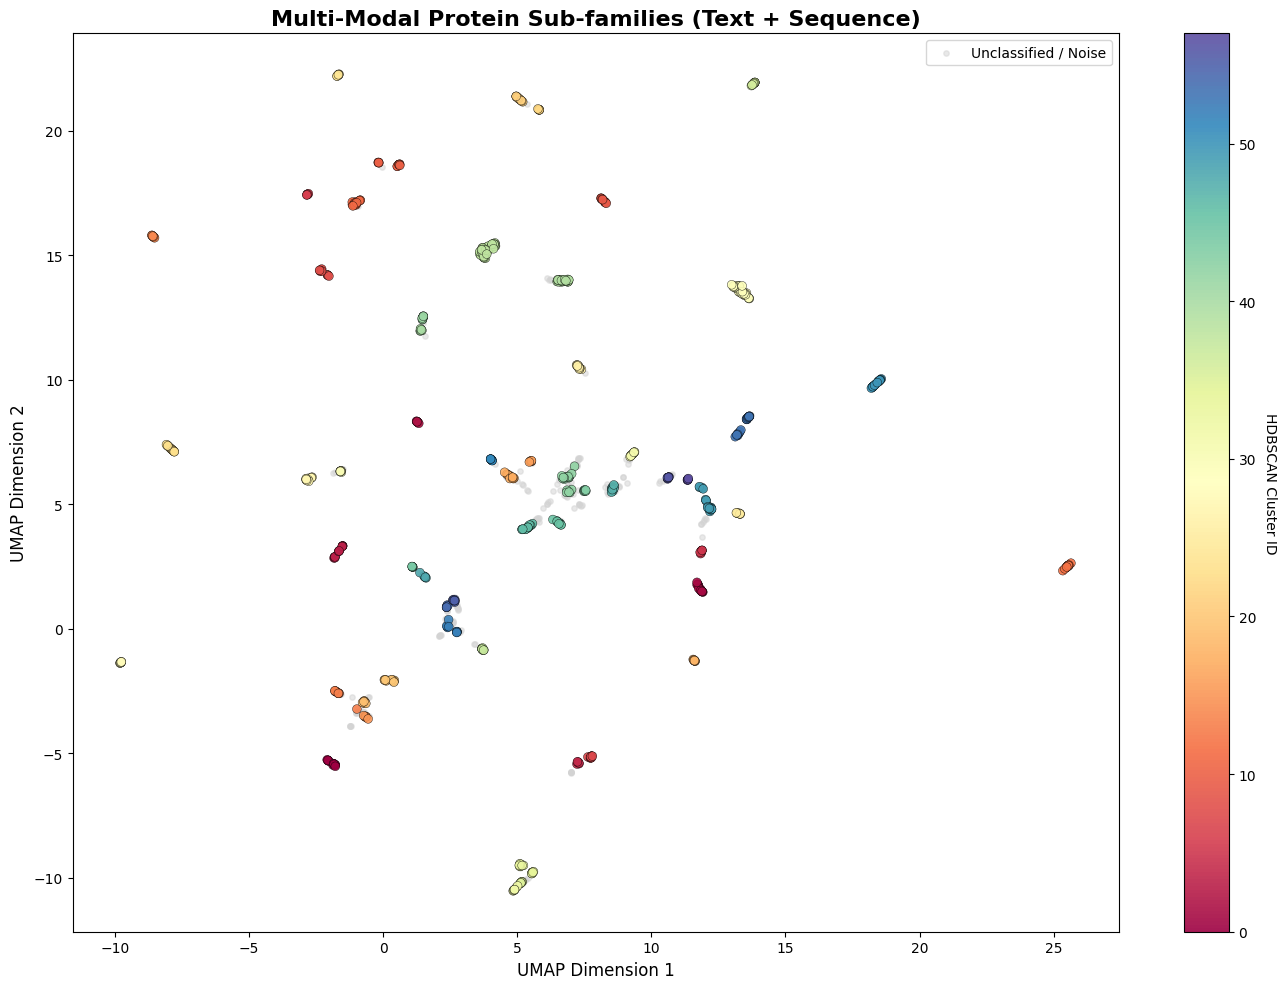

In [41]:
# Initialize UMAP for a precomputed distance matrix
reducer = umap.UMAP(
    n_components=2,
    metric='precomputed',
    random_state=42,
    init='random' 
)

# Compress the 1037x1037 distance matrix down to 2D (x, y) coordinates
embeddings_2d = reducer.fit_transform(super_matrix_dist)

# Set up the figure for the thesis
plt.figure(figsize=(14, 10))

# Plot the "Noise" points (-1) in light grey in the background
noise_mask = labels == -1
plt.scatter(
    embeddings_2d[noise_mask, 0], 
    embeddings_2d[noise_mask, 1], 
    c='lightgrey', 
    s=15, 
    alpha=0.5, 
    label='Unclassified / Noise'
)

# Plot the 34 actual sub-families in bright colors on top
cluster_mask = labels != -1
scatter = plt.scatter(
    embeddings_2d[cluster_mask, 0], 
    embeddings_2d[cluster_mask, 1], 
    c=labels[cluster_mask], 
    cmap='Spectral', 
    s=40, 
    alpha=0.9,
    edgecolors='black', 
    linewidth=0.3
)

plt.title('Multi-Modal Protein Sub-families (Text + Sequence)', fontsize=16, fontweight='bold')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)

cbar = plt.colorbar(scatter)
cbar.set_label('HDBSCAN Cluster ID', rotation=270, labelpad=15)
plt.legend(loc='upper right')
plt.tight_layout()

import os
plt.savefig('../results/figures/multimodal_umap_clusters.png', dpi=300)

plt.show()

**Saving the Final Results**

In [42]:
# Load the original sequence data to grab the 'sequence' and 'subfamily' columns
labeled_seqs = pd.read_csv('../data/processed/sequences_labeled_full.csv')
labeled_seqs = labeled_seqs.rename(columns={'uniref_id': 'ID'})

final_df = pd.merge(text_df, labeled_seqs[['ID', 'sequence', 'subfamily']], on='ID', how='left')
columns_to_keep = [
    'super_cluster',
    'ID',                
    'Protein names',     
    'Gene Names',        
    'Keywords',          
    'Gene Ontology (GO)',     
    'Function [CC]',     
    'sequence',          
    'subfamily'
]

# Keep only the essential columns
final_df = final_df[columns_to_keep]

# ort the DataFrame sequentially by the cluster number
final_df = final_df.sort_values(by='super_cluster').reset_index(drop=True)

final_output_path = '../data/processed/final_multimodal_clusters.csv'
final_df.to_csv(final_output_path, index=False)

print(f"Success! Cleaned and sorted dataset saved to: {final_output_path}")

print(final_df.head())

Success! Cleaned and sorted dataset saved to: ../data/processed/final_multimodal_clusters.csv
   super_cluster          ID  \
0             -1  A0A2R5LMI2   
1             -1  A0A6P4YZI3   
2             -1  A0A8X6IU13   
3             -1  A0A6P8FPZ7   
4             -1  A0A7I8WBH6   

                                       Protein names             Gene Names  \
0  Putative tyramine/octopamine receptor-like pro...                    NaN   
1  Neuropeptide FF receptor 1 (G-protein coupled ...           LOC109473962   
2                        Octopamine receptor beta-2R  Octbeta2R NPIL_109801   
3  Beta-2 adrenergic receptor (Beta-2 adrenorecep...                 adrb2a   
4                                       DgyrCDS13709        DGYR_LOCUS12868   

                                            Keywords  \
0  Cell membrane;G-protein coupled receptor;Membr...   
1  Cell membrane;Disulfide bond;G-protein coupled...   
2  Cell membrane;G-protein coupled receptor;Membr...   
3  Behavior;Ce

### **Clustering Data without uniref id**

In [8]:
textual_data = pd.read_csv("../data/processed/gpcr_text_clusters.csv", index_col=0)
textual_data = textual_data.drop(columns=['hybrid_cluster'])

embbeddings_sequences_mean_pooling = pd.read_csv("../data/processed/embedding_sequences_mean_pooling.csv", index_col=0)
embeddings_normalized = pd.read_csv("../data/processed/embedding_normalized.csv", index_col=0)
embeddings_normalized_2 = pd.read_csv("../data/processed/embedding_normalized_2.csv", index_col=0)

data_normalized_without_id = embeddings_normalized[    ~embeddings_normalized.index.isin(textual_data.index) ]
data_normalized_2_without_id = embeddings_normalized_2[    ~embeddings_normalized_2.index.isin(textual_data.index) ]
data_esm2_mean_pooling_without_id = embbeddings_sequences_mean_pooling[
    ~embbeddings_sequences_mean_pooling.index.isin(textual_data.index)
]

# data_without_id = data_esm2_mean_pooling_without_id.drop(columns=['Protein names','Gene Names','Keywords','Gene Ontology (GO)','Function [CC]'])

# data_normalized_without_id.to_csv("../data/processed/data_normalized_without_id.csv")
# data_normalized_2_without_id.to_csv("../data/processed/data_normalized_2_without_id.csv")
# data_esm2_mean_pooling_without_id.to_csv("../data/processed/data_esm2_mean_pooling_without_id.csv")
print(data_esm2_mean_pooling_without_id.shape)


(961, 1280)


In [26]:
datasets = {
    "normalized":       data_normalized_without_id,
    "normalized_2":     data_normalized_2_without_id,
    "esm2_mean_pooling": data_esm2_mean_pooling_without_id,
}

for name, df in datasets.items():
    print(f"[{name}] shape: {df.shape}")


[normalized] shape: (961, 1281)
[normalized_2] shape: (961, 1281)
[esm2_mean_pooling] shape: (961, 1281)


**Compute ESM-2 Distance Matrix**

In [27]:
distance_matrices = {}

for name, df in datasets.items():
    embeddings = df.values
    sim = cosine_similarity(embeddings)
    dist = np.clip(1 - sim, 0, None)
    np.fill_diagonal(dist, 0)
    distance_matrices[name] = dist
    print(f"[{name}] Distance matrix: {dist.shape}")


[normalized] Distance matrix: (961, 961)
[normalized_2] Distance matrix: (961, 961)
[esm2_mean_pooling] Distance matrix: (961, 961)


**HDBSCAN Clustering**

In [28]:
cluster_labels = {}

for name, dist in distance_matrices.items():
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=5,
        min_samples=5,
        metric='precomputed'
    )
    labels = clusterer.fit_predict(dist)
    cluster_labels[name] = labels
    datasets[name]['cluster'] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = list(labels).count(-1)

    print(f"\n── [{name}] HDBSCAN Results ──")
    print(f"  • Clusters Found : {n_clusters}")
    print(f"  • Noise (-1)     : {n_noise} / {len(labels)}")

    mask = labels != -1
    if mask.sum() > 1:
        sil = silhouette_score(dist[mask][:, mask], labels[mask], metric='precomputed')
        print(f"  • Silhouette Score: {sil:.4f}")
    else:
        print("  • Not enough points for Silhouette Score.")



── [normalized] HDBSCAN Results ──
  • Clusters Found : 26
  • Noise (-1)     : 430 / 961
  • Silhouette Score: 0.5819

── [normalized_2] HDBSCAN Results ──
  • Clusters Found : 27
  • Noise (-1)     : 295 / 961
  • Silhouette Score: 0.4995

── [esm2_mean_pooling] HDBSCAN Results ──
  • Clusters Found : 27
  • Noise (-1)     : 308 / 961
  • Silhouette Score: 0.4185


**UMAP Visualization**

g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


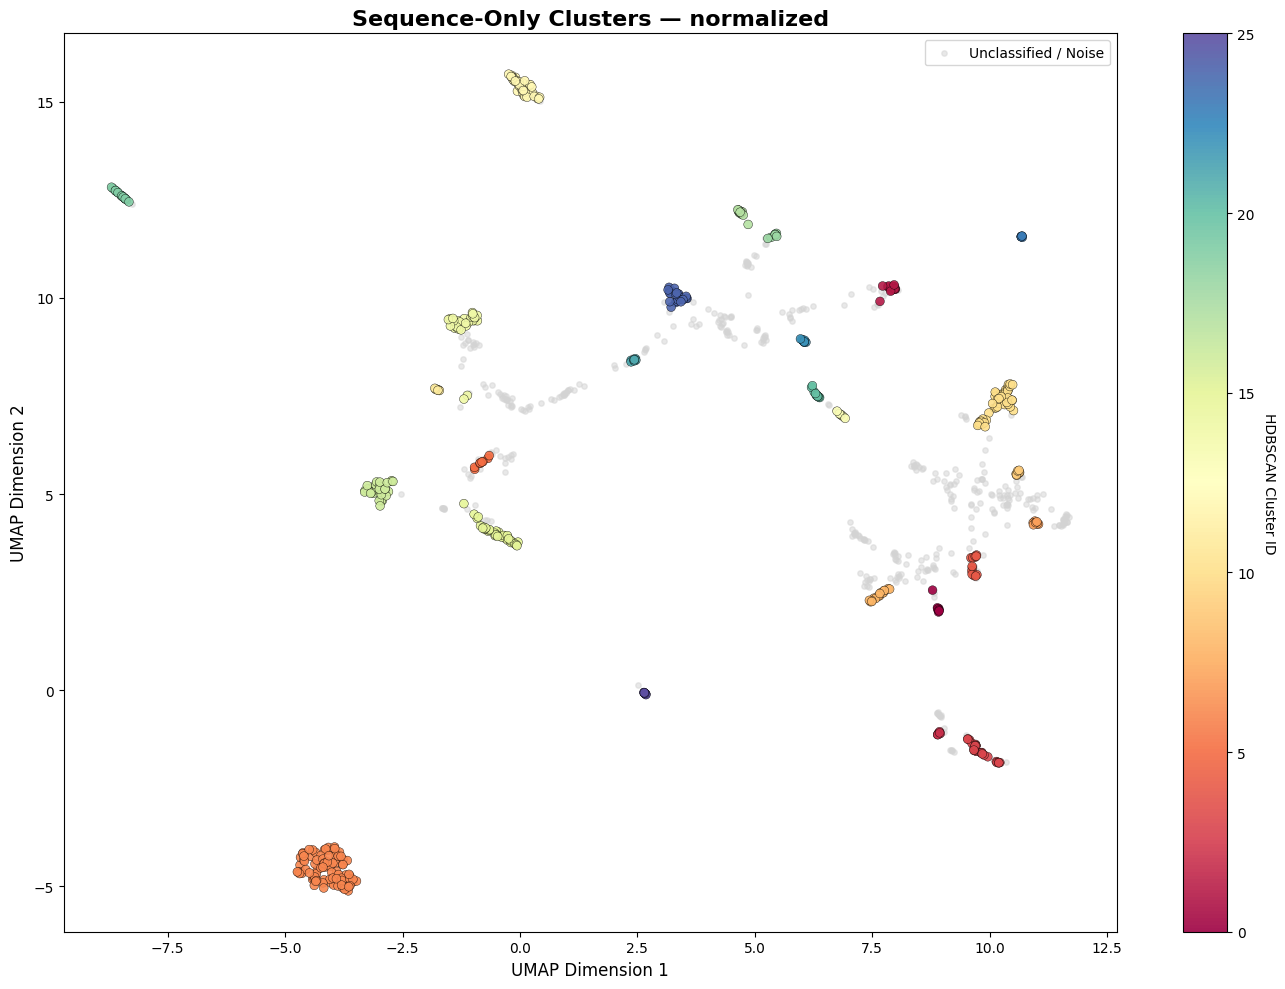

  Saved: sequence_only_umap_normalized.png



g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


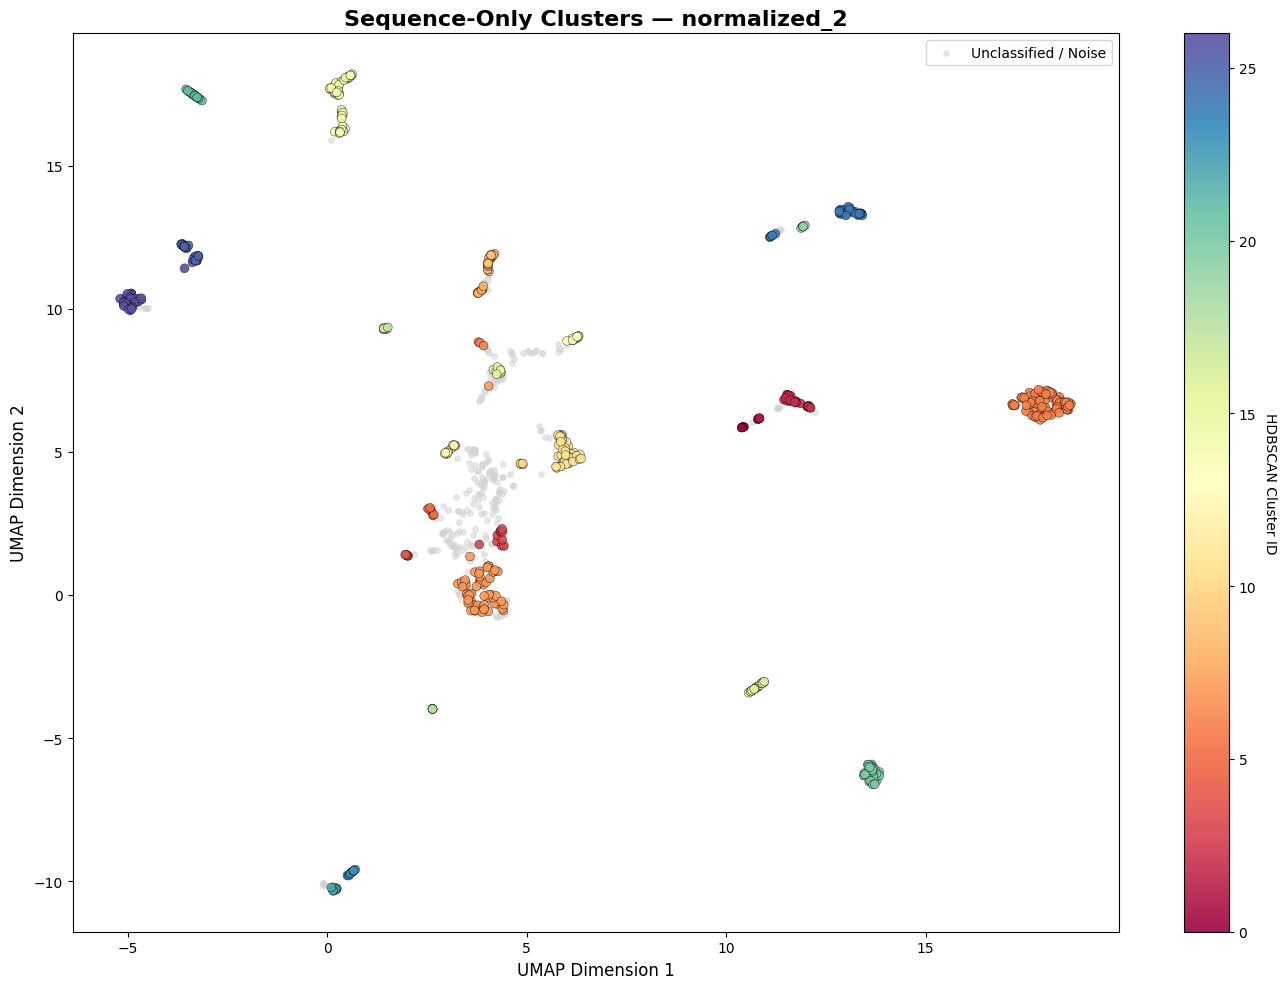

  Saved: sequence_only_umap_normalized_2.png



g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


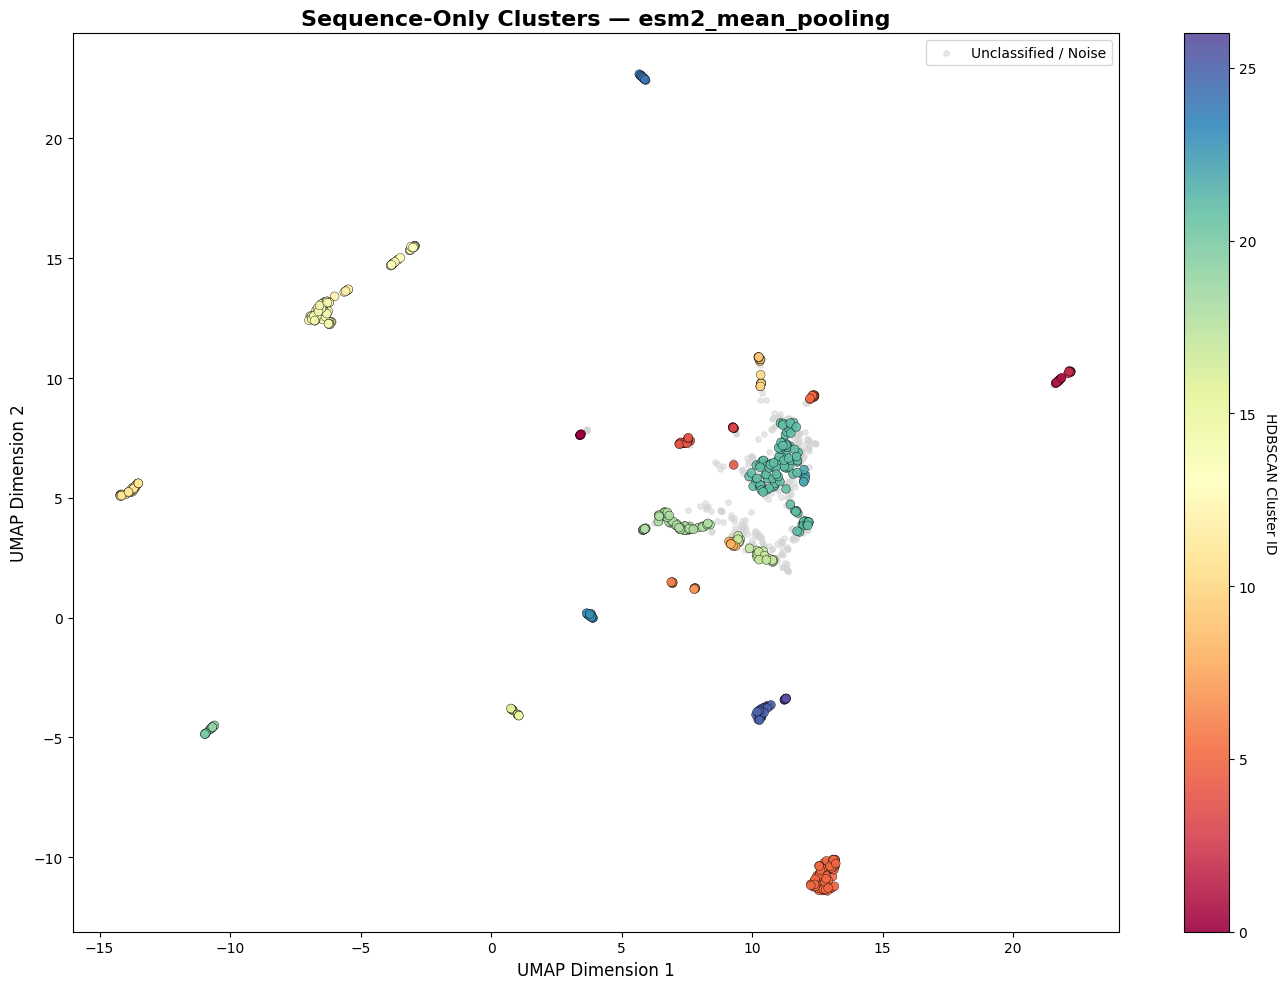

  Saved: sequence_only_umap_esm2_mean_pooling.png



In [29]:
embeddings_2d_all = {}

for name, dist in distance_matrices.items():
    reducer = umap.UMAP(
        n_components=2,
        metric='precomputed',
        random_state=42,
        init='random'
    )
    emb_2d = reducer.fit_transform(dist)
    embeddings_2d_all[name] = emb_2d

    labels = cluster_labels[name]

    plt.figure(figsize=(14, 10))

    # Noise
    noise_mask = labels == -1
    plt.scatter(
        emb_2d[noise_mask, 0], emb_2d[noise_mask, 1],
        c='lightgrey', s=15, alpha=0.5, label='Unclassified / Noise'
    )

    # Clusters
    cluster_mask = labels != -1
    scatter = plt.scatter(
        emb_2d[cluster_mask, 0], emb_2d[cluster_mask, 1],
        c=labels[cluster_mask], cmap='Spectral',
        s=40, alpha=0.9, edgecolors='black', linewidth=0.3
    )

    plt.title(f'Sequence-Only Clusters — {name}', fontsize=16, fontweight='bold')
    plt.xlabel('UMAP Dimension 1', fontsize=12)
    plt.ylabel('UMAP Dimension 2', fontsize=12)
    cbar = plt.colorbar(scatter)
    cbar.set_label('HDBSCAN Cluster ID', rotation=270, labelpad=15)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'../results/figures/sequence_only_umap_{name}.png', dpi=300)
    plt.show()
    print(f"  Saved: sequence_only_umap_{name}.png\n")


*Save Results*

In [30]:
import os

for name, df in datasets.items():
    result = df[['cluster']].copy()
    result.index.name = 'uniref_id'
    result = result.sort_values(by='cluster').reset_index()

    out_path = f'../data/processed/final_sequence_only_clusters_{name}.csv'
    result.to_csv(out_path, index=False)
    print(f"[{name}] Saved → {out_path}")
    print(result['cluster'].value_counts().sort_index().head(10), "\n")


[normalized] Saved → ../data/processed/final_sequence_only_clusters_normalized.csv
cluster
-1    430
 0      9
 1     15
 2      6
 3     26
 4     13
 5      8
 6     94
 7      8
 8     16
Name: count, dtype: int64 

[normalized_2] Saved → ../data/processed/final_sequence_only_clusters_normalized_2.csv
cluster
-1    295
 0      6
 1      6
 2     28
 3     11
 4      8
 5      6
 6     96
 7     68
 8     10
Name: count, dtype: int64 

[esm2_mean_pooling] Saved → ../data/processed/final_sequence_only_clusters_esm2_mean_pooling.csv
cluster
-1    308
 0      6
 1     14
 2      9
 3      7
 4     24
 5     98
 6      5
 7      8
 8      7
Name: count, dtype: int64 

